# Malignant Subtype Classification — MEL / BCC / AK / SCC

Focused on **malignant macro F1**. Macro F1 averages per-class F1 equally, so AK and SCC
(the two rarest classes) dominate the score. Everything here targets those two.

**Five changes from the baseline, in order of expected impact:**

| # | Change | Why it helps macro F1 |
|---|---|---|
| 1 | Clean val/test split | Baseline selected checkpoints *and* reported on the same set — that number is optimistically biased |
| 2 | `WeightedRandomSampler` | Rebalances the training stream from 50/34/9/7 to ~25/25/25/25, so AK/SCC get real gradient signal |
| 3 | Logit adjustment (post-hoc) | Corrects the head-class prior at inference. Costs nothing, tuned on val only |
| 4 | Class-balanced focal loss | Down-weights easy head-class examples; `gamma` focuses on hard rare ones |
| 5 | Multi-scale TTA | Averages 6 views instead of 3 |

**On the custom CNN:** `ARCH = "custom"` trains an SE-ResNet from scratch (7.9M params).
`ARCH = "pretrained"` uses EfficientNet-B3. With ~700 AK and ~500 SCC images, the
pretrained backbone will almost certainly win by a wide margin — from-scratch training
can't learn good low-level features from this little data. Run both and keep the winner.

## Setup

In [1]:
import os, copy, math, pickle, random, warnings
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from torchvision import transforms
from torchvision.models import efficientnet_b3, EfficientNet_B3_Weights

from sklearn.metrics import (accuracy_score, balanced_accuracy_score, f1_score,
                             classification_report, confusion_matrix)
from sklearn.model_selection import train_test_split

from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import boto3

warnings.filterwarnings("ignore")

TRAIN_IMAGE_DIR = "/home/shadeform/data/train/"
EVAL_IMAGE_DIR  = "/home/shadeform/data/test/"
BUCKET_NAME     = "skin-lesion-data-bucket"

MALIGNANT_CLASSES = ["MEL", "BCC", "AK", "SCC"]
NUM_CLASSES = len(MALIGNANT_CLASSES)

CONFIG = {
    "SEED": 42,
    "ARCH": "pretrained",        # "pretrained" (EfficientNet-B3) | "custom" (SE-ResNet from scratch)
    "IMAGE_SIZE": 300,
    "BATCH_SIZE": 32,

    # schedule — custom CNN needs far more epochs than a fine-tune
    "HEAD_WARMUP_EPOCHS": 4,
    "FINE_TUNE_EPOCHS": 45,
    "WARMUP_EPOCHS": 3,
    "EARLY_STOPPING_PATIENCE": 10,

    "HEAD_LR": 1e-4,
    "BACKBONE_LR": 1e-5,
    "CUSTOM_LR": 3e-4,           # single LR when training from scratch
    "WEIGHT_DECAY": 1e-4,

    # --- rare-class levers ---
    "USE_BALANCED_SAMPLER": True,
    "SAMPLER_POWER": 0.5,        # 0 = natural mix, 1 = fully balanced. 0.5 is a good middle
    "LOSS": "cb_focal",          # "cb_focal" | "weighted_ce"
    "FOCAL_GAMMA": 2.0,
    "CLASS_BALANCE_BETA": 0.999,
    "MAX_CLASS_WEIGHT_RATIO": 8.0,
    "LABEL_SMOOTHING": 0.05,

    "MIXUP_ALPHA": 0.2,
    "MIXUP_PROB": 0.3,           # lower than baseline: mixup blurs rare-class boundaries
    "EMA_DECAY": 0.999,
    "GRAD_CLIP_NORM": 1.0,
    "USE_AMP": True,
    "AMP_INIT_SCALE": 2.0 ** 14,

    "TEST_FRACTION": 0.5,        # split the old val set into val (tuning) / test (reporting)
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def set_seed(seed):
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(CONFIG["SEED"])
torch.backends.cudnn.benchmark = True
print(DEVICE, "|", CONFIG["ARCH"])

/home/shadeform/miniconda/envs/skin-lesion-notebooks/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


cuda | pretrained


## Labels — and an honest val/test split

The baseline used `data/test/` as its validation set: early stopping, checkpoint selection,
and the final reported macro F1 all came from the same images. That inflates the reported
number by an amount you can't measure.

Here that set is split in two, stratified by subtype:
- **val** — early stopping, checkpoint selection, logit-adjustment tuning
- **test** — touched exactly once, at the end

Only the test number is reportable.

In [2]:
with open("../../../data/labels/malignant_train.pkl", "rb") as f:
    malignant_train = pickle.load(f)
with open("../../../data/labels/malignant_val.pkl", "rb") as f:
    malignant_eval = pickle.load(f)

eval_names  = np.array(list(malignant_eval.keys()))
eval_labels = np.array([int(v) for v in malignant_eval.values()])

val_names, test_names = train_test_split(
    eval_names, test_size=CONFIG["TEST_FRACTION"],
    stratify=eval_labels, random_state=CONFIG["SEED"])

malignant_val  = {n: malignant_eval[n] for n in val_names}
malignant_test = {n: malignant_eval[n] for n in test_names}

def dist(d):
    c = np.bincount([int(v) for v in d.values()], minlength=NUM_CLASSES)
    return dict(zip(MALIGNANT_CLASSES, c.tolist()))

print("train :", len(malignant_train), dist(malignant_train))
print("val   :", len(malignant_val),   dist(malignant_val))
print("test  :", len(malignant_test),  dist(malignant_test))

train_counts = np.bincount([int(v) for v in malignant_train.values()], minlength=NUM_CLASSES)
print("\ntrain class mix:", (train_counts / train_counts.sum()).round(3))
print("imbalance ratio:", round(train_counts.max() / train_counts.min(), 1), "to 1")

train : 10124 {'MEL': 5321, 'BCC': 3316, 'AK': 1056, 'SCC': 431}
val   : 2444 {'MEL': 1687, 'BCC': 487, 'AK': 187, 'SCC': 83}
test  : 2444 {'MEL': 1687, 'BCC': 488, 'AK': 187, 'SCC': 82}

train class mix: [0.526 0.328 0.104 0.043]
imbalance ratio: 12.3 to 1


## Transforms

In [3]:
IMAGE_SIZE = CONFIG["IMAGE_SIZE"]
MEAN, STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.RandomResizedCrop(IMAGE_SIZE, scale=(0.7, 1.0), ratio=(0.8, 1.25)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomApply([transforms.RandomRotation(30)], p=0.7),
    transforms.ColorJitter(brightness=0.25, contrast=0.25, saturation=0.25, hue=0.05),
    transforms.RandomApply([transforms.GaussianBlur(5, (0.1, 1.5))], p=0.2),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
    transforms.RandomErasing(p=0.3, scale=(0.02, 0.12), ratio=(0.3, 3.3)),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(MEAN, STD),
])

## Dataset & loaders

In [4]:
class MulticlassDataset(Dataset):
    def __init__(self, image_dir, labels_dict, transform=None):
        self.image_dir = image_dir
        self.transform = transform
        self.labels = labels_dict
        self.image_names = list(labels_dict.keys())

    def __len__(self):
        return len(self.image_names)

    def targets(self):
        return np.array([int(self.labels[n]) for n in self.image_names])

    def __getitem__(self, idx):
        name = self.image_names[idx]
        fn = name if "." in name else name + ".jpg"
        path = os.path.join(self.image_dir, fn)
        if not os.path.exists(path):
            path = os.path.join(self.image_dir, name + ".png")
        img = Image.open(path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, int(self.labels[name])


train_ds = MulticlassDataset(TRAIN_IMAGE_DIR, malignant_train, train_transform)
val_ds   = MulticlassDataset(EVAL_IMAGE_DIR,  malignant_val,   eval_transform)
test_ds  = MulticlassDataset(EVAL_IMAGE_DIR,  malignant_test,  eval_transform)

# ---- lever 2: balanced sampling ----
if CONFIG["USE_BALANCED_SAMPLER"]:
    y = train_ds.targets()
    counts = np.bincount(y, minlength=NUM_CLASSES)
    cls_w = (1.0 / counts) ** CONFIG["SAMPLER_POWER"]
    sample_w = cls_w[y]
    sampler = WeightedRandomSampler(torch.as_tensor(sample_w, dtype=torch.double),
                                    num_samples=len(y), replacement=True)
    train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], sampler=sampler,
                              num_workers=8, pin_memory=True, drop_last=True, persistent_workers=True)
    drawn = np.bincount(y[list(iter(sampler))], minlength=NUM_CLASSES)
    print("natural mix :", (counts / counts.sum()).round(3))
    print("sampled mix :", (drawn / drawn.sum()).round(3))
else:
    train_loader = DataLoader(train_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=True,
                              num_workers=8, pin_memory=True, drop_last=True, persistent_workers=True)

val_loader  = DataLoader(val_ds,  batch_size=CONFIG["BATCH_SIZE"], shuffle=False,
                         num_workers=8, pin_memory=True, persistent_workers=True)
test_loader = DataLoader(test_ds, batch_size=CONFIG["BATCH_SIZE"], shuffle=False,
                         num_workers=8, pin_memory=True, persistent_workers=True)

natural mix : [0.526 0.328 0.104 0.043]
sampled mix : [0.39  0.312 0.178 0.12 ]


## Models

Both expose their head as `classifier`, so the same freeze / param-group helpers work
for either. Swap with `CONFIG["ARCH"]`.

In [5]:
class SEBlock(nn.Module):
    def __init__(self, ch, r=16):
        super().__init__()
        h = max(8, ch // r)
        self.fc1 = nn.Conv2d(ch, h, 1); self.fc2 = nn.Conv2d(h, ch, 1)
    def forward(self, x):
        s = F.adaptive_avg_pool2d(x, 1)
        s = torch.sigmoid(self.fc2(F.silu(self.fc1(s))))
        return x * s


class DropPath(nn.Module):
    def __init__(self, p=0.0):
        super().__init__(); self.p = p
    def forward(self, x):
        if self.p == 0.0 or not self.training:
            return x
        keep = 1 - self.p
        return x * x.new_empty(x.shape[0], 1, 1, 1).bernoulli_(keep) / keep


class ResBlock(nn.Module):
    def __init__(self, cin, cout, stride=1, drop_path=0.0):
        super().__init__()
        self.c1 = nn.Conv2d(cin, cout, 3, stride, 1, bias=False); self.b1 = nn.BatchNorm2d(cout)
        self.c2 = nn.Conv2d(cout, cout, 3, 1, 1, bias=False);     self.b2 = nn.BatchNorm2d(cout)
        self.se = SEBlock(cout)
        self.dp = DropPath(drop_path)
        self.short = nn.Identity() if (stride == 1 and cin == cout) else nn.Sequential(
            nn.Conv2d(cin, cout, 1, stride, bias=False), nn.BatchNorm2d(cout))
    def forward(self, x):
        idt = self.short(x)
        o = F.silu(self.b1(self.c1(x)))
        o = self.se(self.b2(self.c2(o)))
        return F.silu(idt + self.dp(o))


class CustomCNN(nn.Module):
    """SE-ResNet trainable from scratch (~7.9M params)."""
    def __init__(self, num_classes=4, widths=(48, 96, 192, 384), depths=(2, 3, 4, 2),
                 dropout=0.4, drop_path=0.1):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, widths[0], 3, 2, 1, bias=False), nn.BatchNorm2d(widths[0]), nn.SiLU(),
            nn.Conv2d(widths[0], widths[0], 3, 1, 1, bias=False), nn.BatchNorm2d(widths[0]), nn.SiLU(),
            nn.MaxPool2d(3, 2, 1))
        blocks, cin, k, total = [], widths[0], 0, sum(depths)
        for si, (w, d) in enumerate(zip(widths, depths)):
            for bi in range(d):
                dp = drop_path * k / max(1, total - 1); k += 1
                blocks.append(ResBlock(cin, w, 2 if (bi == 0 and si > 0) else 1, dp))
                cin = w
        self.features = nn.Sequential(*blocks)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.classifier = nn.Sequential(nn.Dropout(dropout), nn.Linear(cin, num_classes))
    def forward(self, x):
        x = self.features(self.stem(x))
        return self.classifier(torch.flatten(self.pool(x), 1))


def build_model(arch, num_classes=NUM_CLASSES):
    if arch == "pretrained":
        m = efficientnet_b3(weights=EfficientNet_B3_Weights.DEFAULT)
        m.classifier = nn.Sequential(nn.Dropout(0.4),
                                     nn.Linear(m.classifier[1].in_features, num_classes))
    elif arch == "custom":
        m = CustomCNN(num_classes)
    else:
        raise ValueError(arch)
    return m.to(DEVICE)


model = build_model(CONFIG["ARCH"])
HEAD_ATTR = "classifier"
n_params = sum(p.numel() for p in model.parameters())
print(f"{CONFIG['ARCH']}  |  {n_params/1e6:.2f}M params")
with torch.no_grad():
    print("probe:", tuple(model(torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(DEVICE)).shape))

Downloading: "https://download.pytorch.org/models/efficientnet_b3_rwightman-b3899882.pth" to /home/shadeform/.cache/torch/hub/checkpoints/efficientnet_b3_rwightman-b3899882.pth
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 47.2M/47.2M [00:00<00:00, 261MB/s]


pretrained  |  10.70M params
probe: (2, 4)


## Loss — class-balanced focal

Focal loss down-weights examples the model already gets right, so the gradient budget
shifts toward hard cases — which on this data means AK and SCC. Combined with
effective-number class weights, capped so the ratio can't explode.

Note: with `USE_BALANCED_SAMPLER` on, the stream is *already* rebalanced, so the loss
weights are deliberately gentle. Stacking full sampler balancing with full inverse-frequency
loss weights double-counts and makes the model over-predict rare classes.

In [6]:
def effective_num_weights(counts, beta=0.999, max_ratio=8.0):
    counts = np.asarray(counts, dtype=np.float64)
    eff = 1.0 - np.power(beta, counts)
    w = (1.0 - beta) / np.clip(eff, 1e-8, None)
    if w.max() / w.min() > max_ratio:
        w = np.clip(w, None, w.min() * max_ratio)
    return w / w.sum() * len(counts)


class CBFocalLoss(nn.Module):
    def __init__(self, weight=None, gamma=2.0, label_smoothing=0.0):
        super().__init__()
        self.weight, self.gamma, self.ls = weight, gamma, label_smoothing
    def forward(self, logits, target):
        logp = F.log_softmax(logits, dim=1)
        n_cls = logits.size(1)
        if self.ls > 0:
            true_dist = torch.full_like(logp, self.ls / (n_cls - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.ls)
        else:
            true_dist = F.one_hot(target, n_cls).float()
        pt = (logp.exp() * true_dist).sum(1).clamp(1e-8, 1.0)
        ce = -(true_dist * logp).sum(1)
        loss = ((1 - pt) ** self.gamma) * ce
        if self.weight is not None:
            loss = loss * self.weight[target]
        return loss.mean()


counts = np.bincount(train_ds.targets(), minlength=NUM_CLASSES)
# gentler weights when the sampler is already balancing
ratio_cap = 2.5 if CONFIG["USE_BALANCED_SAMPLER"] else CONFIG["MAX_CLASS_WEIGHT_RATIO"]
cls_w = effective_num_weights(counts, CONFIG["CLASS_BALANCE_BETA"], ratio_cap)
cls_w_t = torch.tensor(cls_w, dtype=torch.float32, device=DEVICE)

if CONFIG["LOSS"] == "cb_focal":
    criterion = CBFocalLoss(cls_w_t, CONFIG["FOCAL_GAMMA"], CONFIG["LABEL_SMOOTHING"])
else:
    criterion = nn.CrossEntropyLoss(weight=cls_w_t, label_smoothing=CONFIG["LABEL_SMOOTHING"])

print("counts :", dict(zip(MALIGNANT_CLASSES, counts.tolist())))
print("weights:", dict(zip(MALIGNANT_CLASSES, cls_w.round(3).tolist())))
print("loss   :", CONFIG["LOSS"])

counts : {'MEL': 5321, 'BCC': 3316, 'AK': 1056, 'SCC': 431}
weights: {'MEL': 0.66, 'BCC': 0.682, 'AK': 1.007, 'SCC': 1.651}
loss   : cb_focal


## Training utilities

In [7]:
def mixup_batch(images, labels, alpha):
    if alpha <= 0:
        return images, labels, labels, 1.0
    lam = float(np.random.beta(alpha, alpha))
    perm = torch.randperm(images.size(0), device=images.device)
    return lam * images + (1 - lam) * images[perm], labels, labels[perm], lam


class ModelEMA:
    def __init__(self, model, decay=0.999):
        self.ema = copy.deepcopy(model).eval().to(DEVICE)
        for p in self.ema.parameters():
            p.requires_grad_(False)
        self.decay = decay
    @torch.no_grad()
    def update(self, model):
        mp = dict(model.named_parameters())
        for n, p in self.ema.named_parameters():
            p.mul_(self.decay).add_(mp[n].detach(), alpha=1 - self.decay)
        mb = dict(model.named_buffers())
        for n, b in self.ema.named_buffers():
            b.copy_(mb[n])


def set_backbone_trainable(model, head_attr, trainable):
    for n, p in model.named_parameters():
        if not n.startswith(head_attr):
            p.requires_grad = trainable


def warmup_cosine(optimizer, warmup, total):
    def f(e):
        if e < warmup:
            return (e + 1) / max(1, warmup)
        prog = (e - warmup) / max(1, total - warmup)
        return 0.5 * (1 + math.cos(math.pi * min(prog, 1.0)))
    return optim.lr_scheduler.LambdaLR(optimizer, f)


def train_one_epoch(model, loader, criterion, optimizer, scaler, ema=None,
                    mixup_alpha=0.0, mixup_prob=0.0, grad_clip=None):
    model.train()
    total, nb, skipped = 0.0, 0, 0
    loop = tqdm(loader, leave=False)
    for images, labels in loop:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        if mixup_alpha > 0 and np.random.rand() < mixup_prob:
            x, ya, yb, lam = mixup_batch(images, labels, mixup_alpha)
        else:
            x, ya, yb, lam = images, labels, labels, 1.0

        with torch.autocast(device_type=DEVICE.type,
                            enabled=(CONFIG["USE_AMP"] and DEVICE.type == "cuda")):
            out = model(x)
            loss = lam * criterion(out, ya) + (1 - lam) * criterion(out, yb)

        if not torch.isfinite(loss):
            skipped += 1
            continue

        scaler.scale(loss).backward()
        if grad_clip is not None:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
        scaler.step(optimizer); scaler.update()
        if ema is not None:
            ema.update(model)
        total += loss.item(); nb += 1
        loop.set_postfix(loss=f"{loss.item():.3f}")

    if skipped:
        print(f"  (skipped {skipped} non-finite batches)")
    return total / max(1, nb)


@torch.no_grad()
def collect_logits(model, loader, tta=False):
    """Returns (logits, targets) as numpy — everything downstream works from these."""
    model.eval()
    L, T = [], []
    scales = [1.0, 0.875] if tta else [1.0]
    for images, labels in loader:
        images = images.to(DEVICE, non_blocking=True)
        with torch.autocast(device_type=DEVICE.type,
                            enabled=(CONFIG["USE_AMP"] and DEVICE.type == "cuda")):
            acc, n = 0, 0
            for s in scales:
                x = images if s == 1.0 else F.interpolate(
                    images, scale_factor=s, mode="bilinear", align_corners=False)
                for view in (x, torch.flip(x, [3]), torch.flip(x, [2])):
                    acc = acc + F.log_softmax(model(view).float(), dim=1); n += 1
        L.append((acc / n).cpu().numpy())
        T.append(labels.numpy())
    return np.concatenate(L), np.concatenate(T)


def macro_f1_from_logits(logits, targets):
    return f1_score(targets, logits.argmax(1), average="macro")

## Train

In [8]:
def run_training(model, train_loader, val_loader, criterion, config, ckpt_path):
    scaler = torch.cuda.amp.GradScaler(
        enabled=(config["USE_AMP"] and DEVICE.type == "cuda"), init_scale=config["AMP_INIT_SCALE"])
    history = {"phase": [], "train_loss": [], "val_f1": [], "val_bal_acc": []}
    custom = config["ARCH"] == "custom"

    # ---- Phase 1: head warm-up (pretrained only — from scratch there is nothing to freeze) ----
    if not custom:
        print("=" * 70, "\nPhase 1: head warm-up (backbone frozen)\n", "=" * 70)
        set_backbone_trainable(model, HEAD_ATTR, False)
        opt = optim.AdamW([p for p in model.parameters() if p.requires_grad],
                          lr=config["HEAD_LR"], weight_decay=config["WEIGHT_DECAY"])
        for e in range(config["HEAD_WARMUP_EPOCHS"]):
            tl = train_one_epoch(model, train_loader, criterion, opt, scaler,
                                 grad_clip=config["GRAD_CLIP_NORM"])
            lg, tg = collect_logits(model, val_loader)
            f1 = macro_f1_from_logits(lg, tg)
            print(f"[warmup {e+1}/{config['HEAD_WARMUP_EPOCHS']}] loss {tl:.4f}  val macroF1 {f1:.4f}")
            history["phase"].append("warmup"); history["train_loss"].append(tl)
            history["val_f1"].append(f1)
            history["val_bal_acc"].append(balanced_accuracy_score(tg, lg.argmax(1)))

    # ---- Phase 2: full training ----
    print("\n" + "=" * 70, "\nPhase 2: full network\n", "=" * 70)
    set_backbone_trainable(model, HEAD_ATTR, True)
    if custom:
        opt = optim.AdamW(model.parameters(), lr=config["CUSTOM_LR"],
                          weight_decay=config["WEIGHT_DECAY"])
    else:
        bb = [p for n, p in model.named_parameters() if not n.startswith(HEAD_ATTR)]
        hd = [p for n, p in model.named_parameters() if n.startswith(HEAD_ATTR)]
        opt = optim.AdamW([{"params": bb, "lr": config["BACKBONE_LR"]},
                           {"params": hd, "lr": config["HEAD_LR"]}],
                          weight_decay=config["WEIGHT_DECAY"])

    sched = warmup_cosine(opt, config["WARMUP_EPOCHS"], config["FINE_TUNE_EPOCHS"])
    ema = ModelEMA(model, config["EMA_DECAY"])
    best_f1, stale = -1.0, 0

    for e in range(config["FINE_TUNE_EPOCHS"]):
        lr = opt.param_groups[0]["lr"]
        tl = train_one_epoch(model, train_loader, criterion, opt, scaler, ema=ema,
                             mixup_alpha=config["MIXUP_ALPHA"], mixup_prob=config["MIXUP_PROB"],
                             grad_clip=config["GRAD_CLIP_NORM"])
        sched.step()

        lg_raw, tg = collect_logits(model, val_loader)
        lg_ema, _  = collect_logits(ema.ema, val_loader)
        f1_raw = macro_f1_from_logits(lg_raw, tg)
        f1_ema = macro_f1_from_logits(lg_ema, tg)

        print(f"[ft {e+1}/{config['FINE_TUNE_EPOCHS']}] lr {lr:.2e}  loss {tl:.4f}  "
              f"val macroF1 raw {f1_raw:.4f} | ema {f1_ema:.4f}")

        cand_f1, cand_state, tag = ((f1_ema, ema.ema.state_dict(), "EMA") if f1_ema >= f1_raw
                                    else (f1_raw, model.state_dict(), "raw"))
        history["phase"].append("finetune"); history["train_loss"].append(tl)
        history["val_f1"].append(max(f1_raw, f1_ema))
        history["val_bal_acc"].append(balanced_accuracy_score(
            tg, (lg_ema if f1_ema >= f1_raw else lg_raw).argmax(1)))

        if cand_f1 > best_f1:
            best_f1, stale = cand_f1, 0
            torch.save(copy.deepcopy(cand_state), ckpt_path)
            print(f"    saved ({tag}, macroF1 {best_f1:.4f})")
        else:
            stale += 1
            if stale >= config["EARLY_STOPPING_PATIENCE"]:
                print(f"\nEarly stop at epoch {e+1} (best {best_f1:.4f})")
                break

    return history, best_f1


CKPT = f"best_malignant_{CONFIG['ARCH']}.pth"
history, best_val_f1 = run_training(model, train_loader, val_loader, criterion, CONFIG, CKPT)
print(f"\nBest VAL macro F1: {best_val_f1:.4f}   (selection metric — not the reportable number)")

Phase 1: head warm-up (backbone frozen)


[warmup 1/4] loss 0.5958  val macroF1 0.3051


[warmup 2/4] loss 0.5304  val macroF1 0.3328


[warmup 3/4] loss 0.4917  val macroF1 0.3317


[warmup 4/4] loss 0.4802  val macroF1 0.3431

Phase 2: full network


...

[ft 26/45] lr 4.63e-06  loss 0.1924  val macroF1 raw 0.4423 | ema 0.4385


[ft 27/45] lr 4.25e-06  loss 0.1946  val macroF1 raw 0.4387 | ema 0.4334


[ft 28/45] lr 3.89e-06  loss 0.1892  val macroF1 raw 0.4378 | ema 0.4341


[ft 29/45] lr 3.53e-06  loss 0.1881  val macroF1 raw 0.4421 | ema 0.4367


[ft 30/45] lr 3.17e-06  loss 0.1910  val macroF1 raw 0.4391 | ema 0.4372

Early stop at epoch 30 (best 0.4443)

Best VAL macro F1: 0.4443   (selection metric — not the reportable number)


## Logit adjustment — tuned on VAL only

The model inherits the training prior and over-predicts MEL/BCC. Subtracting
`tau * log(prior)` from the logits corrects that at inference, with no retraining.

`tau` is searched on **val**. Test is not touched here — using test to pick `tau` would
put the reported score right back where the baseline was.

tau=0 (plain argmax) val macro F1 : 0.4411
tau=0.0 (adjusted)         val macro F1 : 0.4411
gain on val                       : +0.0000


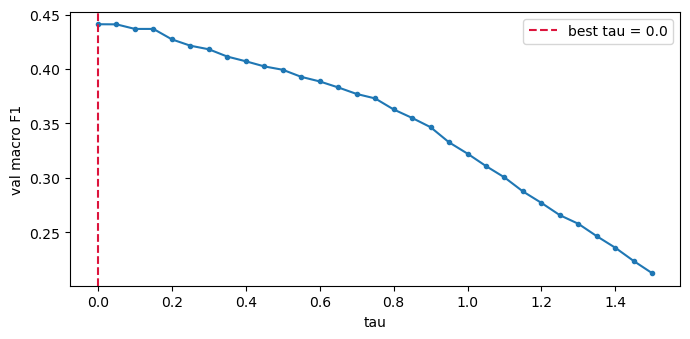

In [9]:
model.load_state_dict(torch.load(CKPT, map_location=DEVICE))
model.to(DEVICE).eval()

val_logits, val_targets = collect_logits(model, val_loader, tta=True)

prior = np.log(counts / counts.sum())
rows = []
for tau in np.arange(0.0, 1.51, 0.05):
    f1 = f1_score(val_targets, (val_logits - tau * prior).argmax(1), average="macro")
    rows.append({"tau": round(tau, 2), "val_macro_f1": round(f1, 4)})

tau_df = pd.DataFrame(rows)
BEST_TAU = float(tau_df.loc[tau_df["val_macro_f1"].idxmax(), "tau"])
base_f1 = tau_df.loc[tau_df["tau"] == 0.0, "val_macro_f1"].iloc[0]
best_f1 = tau_df["val_macro_f1"].max()

print(f"tau=0 (plain argmax) val macro F1 : {base_f1:.4f}")
print(f"tau={BEST_TAU} (adjusted)         val macro F1 : {best_f1:.4f}")
print(f"gain on val                       : {best_f1 - base_f1:+.4f}")

plt.figure(figsize=(7, 3.5))
plt.plot(tau_df["tau"], tau_df["val_macro_f1"], marker="o", ms=3)
plt.axvline(BEST_TAU, color="crimson", ls="--", label=f"best tau = {BEST_TAU}")
plt.xlabel("tau"); plt.ylabel("val macro F1"); plt.legend(); plt.tight_layout(); plt.show()

## Final evaluation — TEST set, touched once

Everything above (checkpoint, `tau`) was chosen using train and val only.
This is the number to report.

In [10]:
test_logits, test_targets = collect_logits(model, test_loader, tta=True)

results = {}
for name, lg in [("argmax", test_logits),
                 ("logit-adjusted", test_logits - BEST_TAU * prior)]:
    pred = lg.argmax(1)
    results[name] = {
        "accuracy": accuracy_score(test_targets, pred),
        "balanced_accuracy": balanced_accuracy_score(test_targets, pred),
        "macro_f1": f1_score(test_targets, pred, average="macro"),
    }

summary = pd.DataFrame(results).T.round(4)
print(summary.to_string(), "\n")

FINAL_PRED = (test_logits - BEST_TAU * prior).argmax(1)
print(classification_report(test_targets, FINAL_PRED,
                            target_names=MALIGNANT_CLASSES, digits=4, zero_division=0))

per_class = pd.DataFrame({
    "class": MALIGNANT_CLASSES,
    "support": np.bincount(test_targets, minlength=NUM_CLASSES),
    "f1_argmax": f1_score(test_targets, test_logits.argmax(1), average=None,
                          labels=range(NUM_CLASSES), zero_division=0).round(4),
    "f1_adjusted": f1_score(test_targets, FINAL_PRED, average=None,
                            labels=range(NUM_CLASSES), zero_division=0).round(4),
})
per_class["delta"] = (per_class["f1_adjusted"] - per_class["f1_argmax"]).round(4)
print("\nPer-class F1 — where the macro score comes from:")
print(per_class.to_string(index=False))

                accuracy  balanced_accuracy  macro_f1
argmax            0.5303             0.5449    0.4234
logit-adjusted    0.5303             0.5449    0.4234 

              precision    recall  f1-score   support

         MEL     0.9084    0.4641    0.6144      1687
         BCC     0.3996    0.7746    0.5272       488
          AK     0.2661    0.5508    0.3589       187
         SCC     0.1285    0.3902    0.1934        82

    accuracy                         0.5303      2444
   macro avg     0.4256    0.5449    0.4234      2444
weighted avg     0.7315    0.5303    0.5633      2444


Per-class F1 — where the macro score comes from:
class  support  f1_argmax  f1_adjusted  delta
  MEL     1687     0.6144       0.6144    0.0
  BCC      488     0.5272       0.5272    0.0
   AK      187     0.3589       0.3589    0.0
  SCC       82     0.1934       0.1934    0.0


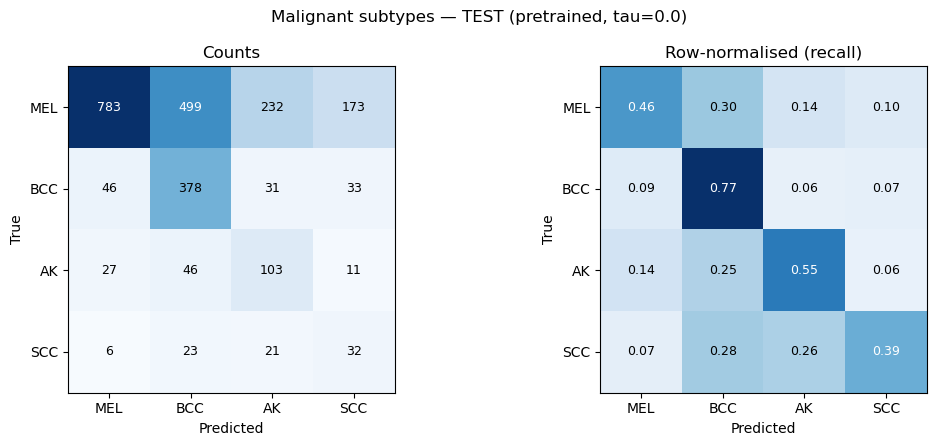

Weakest class: SCC (F1 0.1934, n=82)
Its most common confusion: BCC


In [11]:
cm = confusion_matrix(test_targets, FINAL_PRED, labels=range(NUM_CLASSES))
cm_norm = cm / np.clip(cm.sum(1, keepdims=True), 1, None)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, mat, title, fmt in [(axes[0], cm, "Counts", "d"),
                            (axes[1], cm_norm, "Row-normalised (recall)", ".2f")]:
    im = ax.imshow(mat, cmap="Blues", vmin=0)
    ax.set_xticks(range(NUM_CLASSES)); ax.set_yticks(range(NUM_CLASSES))
    ax.set_xticklabels(MALIGNANT_CLASSES); ax.set_yticklabels(MALIGNANT_CLASSES)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True"); ax.set_title(title)
    thr = mat.max() / 2
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, format(mat[i, j], fmt), ha="center", va="center",
                    color="white" if mat[i, j] > thr else "black", fontsize=9)
plt.suptitle(f"Malignant subtypes — TEST ({CONFIG['ARCH']}, tau={BEST_TAU})")
plt.tight_layout(); plt.show()

worst = per_class.sort_values("f1_adjusted").iloc[0]
print(f"Weakest class: {worst['class']} (F1 {worst['f1_adjusted']:.4f}, n={worst['support']})")
print("Its most common confusion:",
      MALIGNANT_CLASSES[np.argsort(-cm[MALIGNANT_CLASSES.index(worst['class'])])[
          0 if np.argmax(cm[MALIGNANT_CLASSES.index(worst['class'])]) !=
          MALIGNANT_CLASSES.index(worst['class']) else 1]])

## Training curves

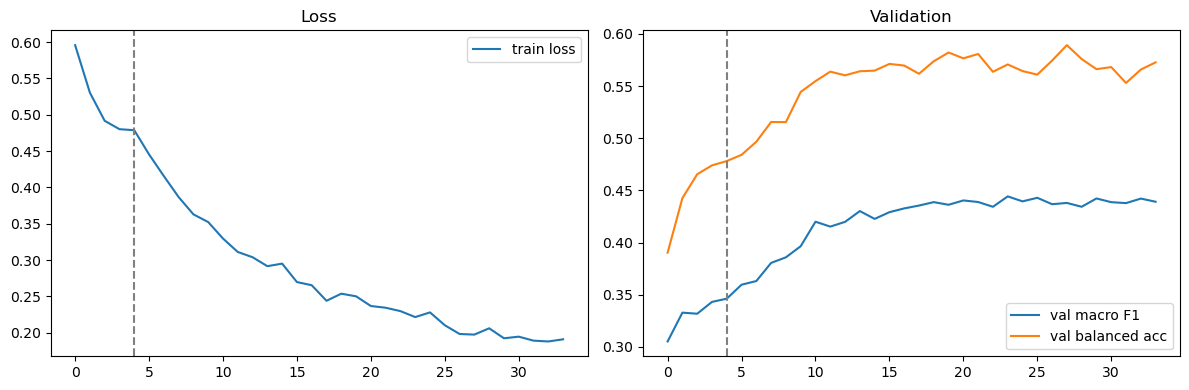

In [12]:
h = pd.DataFrame(history)
boundary = (h["phase"] == "finetune").idxmax() if "warmup" in h["phase"].values else 0

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(h["train_loss"], label="train loss")
axes[0].axvline(boundary, color="gray", ls="--"); axes[0].set_title("Loss"); axes[0].legend()
axes[1].plot(h["val_f1"], label="val macro F1")
axes[1].plot(h["val_bal_acc"], label="val balanced acc")
axes[1].axvline(boundary, color="gray", ls="--"); axes[1].set_title("Validation"); axes[1].legend()
plt.tight_layout(); plt.show()

## Save to S3

In [ ]:
out_dir = f"saved_models/{CONFIG['ARCH']}_malignant_subtype"
os.makedirs(out_dir, exist_ok=True)
local = f"{out_dir}/malignant_subtype_checkpoint.pth"

torch.save({
    "model_state_dict": model.state_dict(),
    "arch": CONFIG["ARCH"],
    "class_names": MALIGNANT_CLASSES,
    "config": CONFIG,
    "image_size": IMAGE_SIZE,
    "logit_adjust_tau": BEST_TAU,
    "train_class_counts": counts.tolist(),
    "log_prior": prior.tolist(),
    "val_macro_f1": float(best_val_f1),
    "test_macro_f1": float(results["logit-adjusted"]["macro_f1"]),
    "test_balanced_accuracy": float(results["logit-adjusted"]["balanced_accuracy"]),
}, local)

s3 = boto3.client("s3")
key = f"{out_dir}/malignant_subtype_checkpoint.pth"
s3.upload_file(local, BUCKET_NAME, key)
print(f"Uploaded -> s3://{BUCKET_NAME}/{key}")
print(f"TEST macro F1: {results['logit-adjusted']['macro_f1']:.4f}")

## Compare architectures

Set `CONFIG["ARCH"] = "custom"`, restart from the model cell, and record the test macro F1.
Everything needed to reproduce inference is in the checkpoint: `arch`, `image_size`,
`logit_adjust_tau`, and `log_prior`.

**At inference, apply the same adjustment or the scores won't reproduce:**

```python
logits = model(x)
pred = (logits.cpu().numpy() - ckpt["logit_adjust_tau"] * np.array(ckpt["log_prior"])).argmax(1)
```

**If macro F1 is still low, look at the per-class table before changing anything.**
A low AK or SCC F1 with high recall but low precision means `tau` is too high; the reverse
means the sampler needs `SAMPLER_POWER` closer to 1. Chasing hyperparameters without
reading that table wastes GPU hours.